In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gmudit/employer-data/Employers_data.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/gmudit/employer-data

In [3]:
data = pd.read_csv('/kaggle/input/datasets/gmudit/employer-data/Employers_data.csv')
df = pd.DataFrame(data)
df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


### EDA and Feature Engineering

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.455900,12.370900,115381.500000
std,2886.89568,10.000213,9.148951,46066.139047
min,1.00000,21.000000,0.000000,25000.000000
25%,2500.75000,27.000000,5.000000,70000.000000
50%,5000.50000,34.000000,10.000000,120000.000000
75%,7500.25000,43.000000,19.000000,150000.000000
max,10000.00000,60.000000,37.000000,215000.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


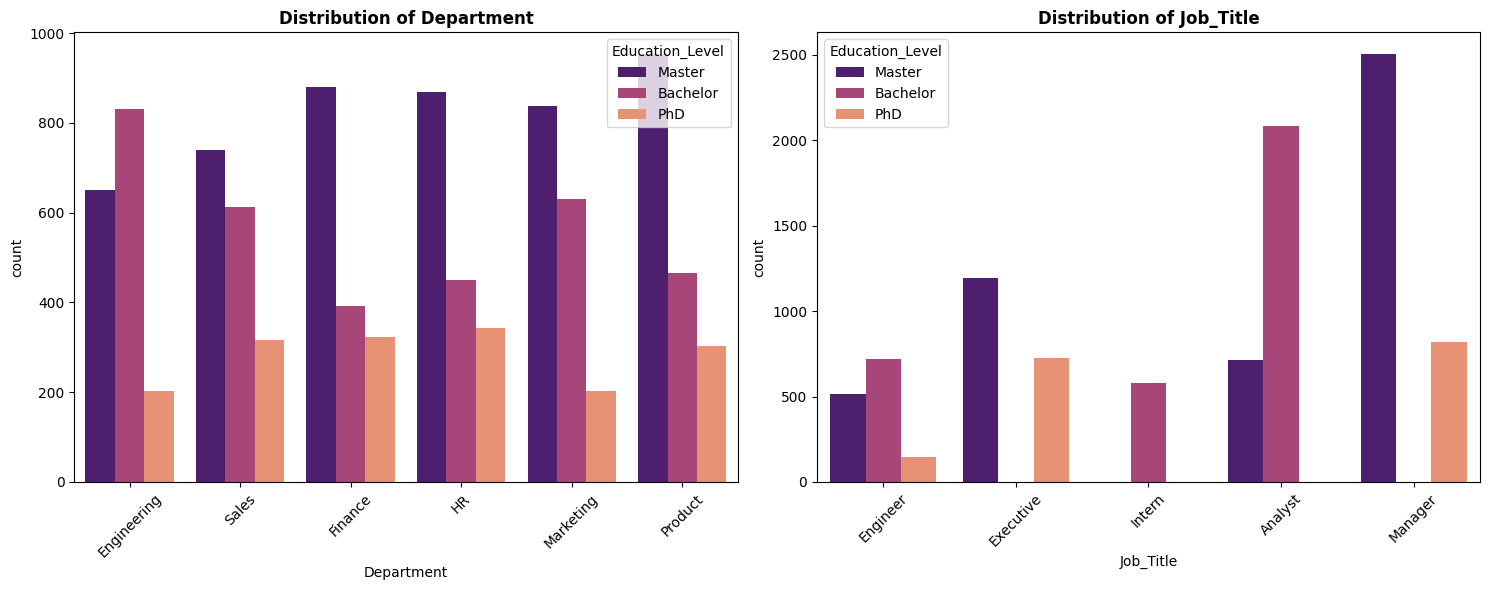

In [8]:
columns_to_plot = ['Department', 'Job_Title']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, col in enumerate(columns_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], palette='magma',hue="Education_Level")
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout() 
plt.show()

In [9]:
df["Location"].value_counts()

Location
Austin           2034
Seattle          2017
Chicago          2008
New York         1980
San Francisco    1961
Name: count, dtype: int64

In [10]:
df.columns

Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title',
       'Experience_Years', 'Education_Level', 'Location', 'Salary'],
      dtype='object')

<Axes: xlabel='Age', ylabel='Salary'>

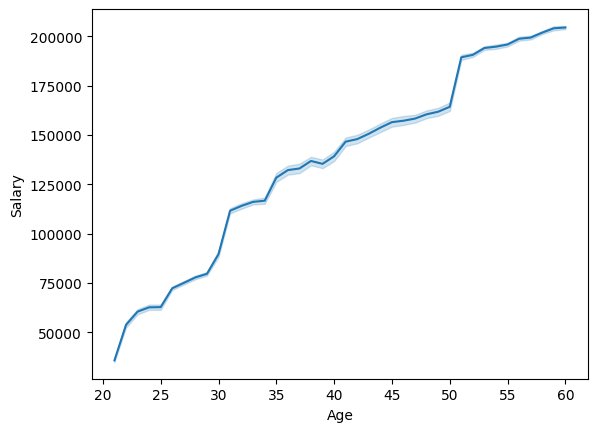

In [11]:
sns.lineplot(data=df,x='Age',y='Salary')

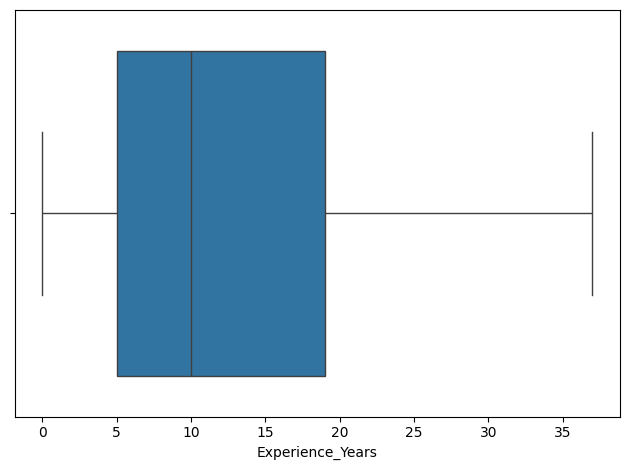

In [12]:
sns.boxplot(data=df,x='Experience_Years')
plt.tight_layout()

<Axes: >

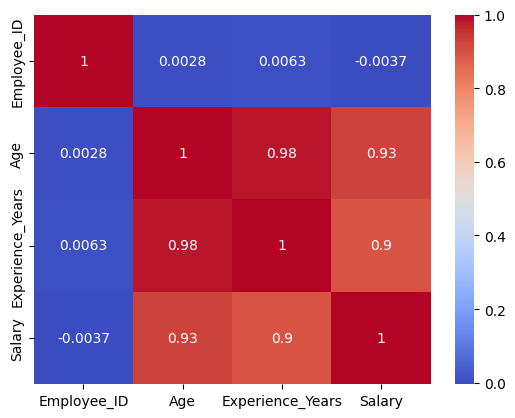

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [14]:
# Removing Irrelevant Columns
df = df.drop(['Employee_ID', 'Name'], axis=1)
df.head()

,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,56,Male,Sales,Executive,33,Master,Seattle,195000
2,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,25,Female,HR,Analyst,2,Master,Seattle,70000


# ML

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import root_mean_squared_error,mean_squared_error, r2_score

### Encoding Categorical Columns

In [16]:
df.columns

Index(['Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years',
       'Education_Level', 'Location', 'Salary'],
      dtype='object')

In [17]:
df = df.rename(columns={'Gender' : 'is_Female'})
df['is_Female'] = df['is_Female'].map({'Female' : 1,'Male' : 0})
df.head()

,Age,is_Female,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,24,1,Engineering,Engineer,1,Master,Austin,90000
1,56,0,Sales,Executive,33,Master,Seattle,195000
2,21,0,Engineering,Intern,1,Bachelor,New York,35000
3,30,0,Finance,Analyst,9,Bachelor,New York,75000
4,25,1,HR,Analyst,2,Master,Seattle,70000


In [18]:
df['Location'].value_counts()

Location
Austin           2034
Seattle          2017
Chicago          2008
New York         1980
San Francisco    1961
Name: count, dtype: int64

In [19]:
df = pd.get_dummies(data=df,columns=['Department','Job_Title','Education_Level','Location'],drop_first = True,dtype=int)
df.head()

,Age,is_Female,Experience_Years,Salary,Department_Finance,Department_HR,Department_Marketing,Department_Product,Department_Sales,Job_Title_Engineer,Job_Title_Executive,Job_Title_Intern,Job_Title_Manager,Education_Level_Master,Education_Level_PhD,Location_Chicago,Location_New York,Location_San Francisco,Location_Seattle
0,24,1,1,90000,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
1,56,0,33,195000,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1
2,21,0,1,35000,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3,30,0,9,75000,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,25,1,2,70000,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1


In [20]:
df.shape

(10000, 19)

### Standard Scalar

In [21]:
X = df.drop(columns=['Salary'])
y = df['Salary']

In [22]:
# 1. Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize scaler
scaler = StandardScaler()

# 3. Scaling only those who doesn't have boolean values
cols_to_scale = ['Age', 'Experience_Years']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# 4. Transform ONLY (no fitting!) the Test data
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(X_train[cols_to_scale].head())

           Age  Experience_Years
9254  1.450139          1.591311
1561 -1.146774         -1.352835
1670  1.450139          1.155141
6087 -0.547487         -1.025708
6669 -0.547487         -0.589538


In [23]:
# Defining Model in Dictionary for easy iteration
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=5),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

In [24]:
# Initialize a list to store results
model_comparison = []

# Loop through the dictionary
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate both
    mse = mean_squared_error(y_test, y_pred) # Stays in squared units
    rmse = root_mean_squared_error(y_test, y_pred) # Back to original units
    r2 = r2_score(y_test, y_pred)
    
    model_comparison.append({
        'Model': name,
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })
# Convert to DataFrame
results_df = pd.DataFrame(model_comparison).sort_values(by='R2 Score', ascending=False)
print(results_df)

               Model           MSE      RMSE  R2 Score
0  Linear Regression  1.737502e+07   4168.34    0.9918
1              Ridge  1.740227e+07   4171.60    0.9917
2              Lasso  1.753035e+07   4186.93    0.9917
3         ElasticNet  2.928940e+08  17114.15    0.8610
